In [ ]:
# This script sets up the VPint & VPint2 library environment in Google Colab.
# It performs a clean installation, clones the repository, installs dependencies,
# and prepares the environment for satellite imagery interpolation tasks using VPint2
#
# Resources:
# - TPU requirement: Used TPU v6e1. GPU acceleration is beneficial for interpolation.
#
# - TEST5_SONGADH (PATCH): Processing time per for a 5 km x 5 km window patch - SONGADH:
#   - Approx 15 mins
#
# ----------PERFORMANCE ASSESSMENT---------
#
# Authors:
# - Jayson J. Jariwala
# - Mewan Banshan War
# - Arkadipta Das
# - Venkatesh Nayak
#
# Study Area: TAPI sub-districts, near SURAT (specifically TAPI sub-district 5 km x 5 km window patch for processing).
#

In [ ]:
# Go to the root content directory to ensure consistent cloning location
%cd /content

# [A]. Aggressive cleanup of any previous VPint installations

# Uninstall any previously installed VPint package
!pip uninstall -y VPint

# Remove any cloned VPint directories
# !rm -rf VPint VPint2 # Remove cloned directories
!rm -rf VPint
!rm -rf VPint2

# Explicitly remove the egg file that seems to cause persistent issues
!rm -rf /usr/local/lib/python3.12/dist-packages/VPint-0.2.4-py3.12.egg
!rm -rf /usr/local/lib/python3.12/dist-packages/VPint.egg-info/

/content


In [ ]:
# [B]. Clone the VPint repository from LaurensArp
# installation. To create a new environment for VPint2 using conda,
# Conda is not installed by default in Colab. Using pip for package installation.
!git clone https://github.com/LaurensArp/VPint.git

# Change into the cloned directory
%cd VPint

# Install dependencies from requirements.txt
!pip install -r requirements.txt

# 3. Install the package in editable mode to ensure correct path resolution
!python setup.py install
!pip install -e .

fatal: destination path 'VPint' already exists and is not an empty directory.
/content/VPint
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/VPint-0.2.4-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
running install
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()
/usr/local/lib/python3.12/di

In [ ]:
# [C]
# This section imports the necessary classes and utility functions from the VPint library.
# It ensures that the required components like 'VPint2_interpolator' and
# 'load_product', 'normalise_and_visualise' from 'EO_utils' are available for use.

#Import VPint modules, check before running main module

# VPint2_interpolator is found in VPint/VPint2.py
from VPint.VPint2 import VPint2_interpolator

# from VPint.utils.EO_wrapper import load_product, load_product_windowed, normalise_and_visualise
from VPint.utils.EO_utils import load_product, load_product_windowed, normalise_and_visualise, normalise_and_visualise_single

# Numpy is also imported for numerical operations.
import numpy as np

In [ ]:
# [D]. Verify VPint & VPint2
# This section verifies the successful installation and accessibility of the VPint library
# by listing directory contents and displaying the content of key Python files.

# Verify the contents of the root cloned directory
!ls -F /content/VPint

# Verify the contents of the actual Python package directory
!ls -F /content/VPint/VPint

# Now, try to cat the files from their correct paths
!cat /content/VPint/VPint/VPint2.py

# !cat /content/VPint2/VPint/utils/EO_wrapper.py
!cat /content/VPint/VPint/utils/EO_wrapper.py

!cat /content/VPint/README.md

build/	examples/    README.md		    setup.py  VPint.egg-info/
dist/	LICENSE      requirements_slim.txt  test/
docs/	MANIFEST.in  requirements.txt	    VPint/
__init__.py  MRP.py  __pycache__/  SD_MRP.py  utils/  VPint2.py  WP_MRP.py
"""Wrapper for VPint code; most of the VPint2 functionality is already contained in the core code.
This module aims to improve the ease of use of VPint2 for EO tasks.
"""

import numpy as np

import multiprocessing


from .WP_MRP import *

class VPint2_interpolator():
    def __init__(self, target, features, mask=None, buffer_mask=False, mask_buffer_size=5, mask_buffer_passes=1, bands_first=False, clip_target=None, clip_features=None, dtype=None, **kwargs):
        assert target.shape == features.shape
        assert len(target.shape) == 3
        assert len(features.shape) == 3

        if(dtype is not None):
            self.DTYPE = dtype
        else:
            self.DTYPE = np.float32

        target = target.astype(self.DTYPE)
        features = feature

In [ ]:
#import inspect
#from VPint.utils.EO_utils import load_product

#print(inspect.getsource(load_product))

In [ ]:
# [E]. Mount Google Drive to access files

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


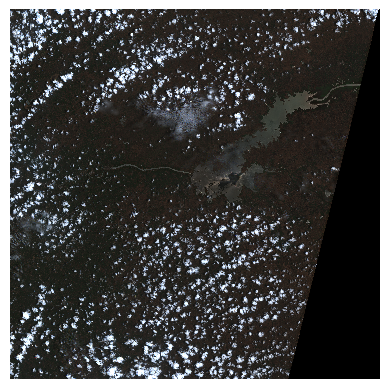

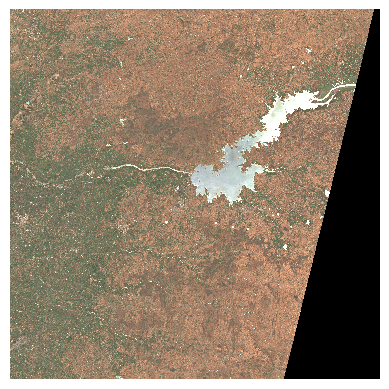

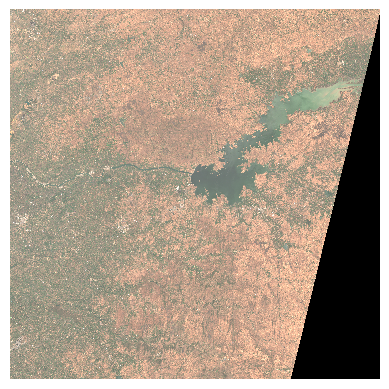

In [ ]:
# [F]. Data Loading and Visualization
# This section covers the initial data loading and visualization steps. We load the cloudy target image and the cloud-free features image from our prepared dataset. These images are then normalized and displayed to provide a visual understanding of the input data before any interpolation is applied.

# Import necessary classes from VPint library for interpolation and utility functions
from VPint.VPint2 import VPint2_interpolator
from VPint.utils.EO_utils import load_product, load_product_windowed, normalise_and_visualise, normalise_and_visualise_single
import rasterio # Import rasterio for georeferencing extraction

# Define the path to the target satellite imagery data (cloudy image)
# target_path = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2B_MSIL2A_20250513T052649_N0511_R105_T43QCD_20250513T074137.zip"
target_path = "/content/drive/MyDrive/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip"
# CLOUD-FREE image
target_ref_path = "/content/drive/MyDrive/EarthLens/Assignment-II/DATASET/SURAT/Target_Image/S2C_MSIL2A_20250501T053701_N0511_R005_T43QCD_20250501T102217.SAFE.zip"
# Define the path to the features satellite imagery data (cloud-free image for reference)
#features_path = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2B_MSIL2A_20250314T052649_N0511_R105_T43QCD_20250314T095315.zip"
features_path = "/content/drive/MyDrive/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.zip"

# Load the cloudy target product using the VPint utility function
target = load_product(target_path)
# Load the cloud-free target product using the VPint utility function
target_ref = load_product(target_ref_path)
# Load the features product using the VPint utility function
features = load_product(features_path)

# Extract georeferencing information from one of the subdatasets of the target product
original_transform = None
original_crs = None
with rasterio.open(target_path) as raw_product:
    product_subdatasets = raw_product.subdatasets
    if product_subdatasets:
        # Open the first subdataset to get its transform and CRS
        with rasterio.open(product_subdatasets[0]) as src:
            original_transform = src.transform
            original_crs = src.crs

# Normalise and visualise the cloudy target image for inspection
normalise_and_visualise(target)
# Normalise and visualise the cloud-free target image for inspection
normalise_and_visualise(target_ref)
# Normalise and visualise the features image for inspection
normalise_and_visualise(features)

In [ ]:
# [INPUT]: Select a Sub-District
# This section allows you to choose a target sub-district from the provided shapefile.
# The selected name will be used in the subsequent [EXTRA-1] section for processing.

!pip install geopandas # Install geopandas if not already installed
import geopandas as gpd

# === User configuration for input selection ===
shapefile_path = "/content/drive/MyDrive/EarthLens/Assignment-II/DATASET/SURAT/SHP/SUB_DISTR/surat_sd.shp"
name_field_for_selection = "Sub_Distri" # The attribute field in your shapefile containing sub-district names

# Load the shapefile to get available sub-district names
try:
    gdf_selection = gpd.read_file(shapefile_path)
    if gdf_selection is None or gdf_selection.empty:
        raise RuntimeError("Shapefile could not be read or is empty. Check shapefile_path.")

    # Normalize names by stripping spaces
    gdf_selection[name_field_for_selection] = gdf_selection[name_field_for_selection].astype(str).str.strip()

    # Get unique sub-district names
    available_sub_districts = sorted(gdf_selection[name_field_for_selection].unique().tolist())

    print("\nAvailable Sub-Districts:")
    for i, name in enumerate(available_sub_districts):
        print(f"{i+1}. {name}")

    while True:
        try:
            choice = input("Enter the number corresponding to your desired sub-district: ")
            choice_idx = int(choice) - 1
            if 0 <= choice_idx < len(available_sub_districts):
                selected_sub_district = available_sub_districts[choice_idx]
                print(f"\nSelected Sub-District: {selected_sub_district}")
                break
            else:
                print("Invalid number. Please enter a number from the list.")
        except ValueError:
            print("Invalid input. Please enter a number.")

except Exception as e:
    print(f"Error in sub-district selection: {e}")
    print("Defaulting to 'Songadh' for processing.")
    selected_sub_district = "Songadh"

# This variable will be used in the next cell(s).
# If you run this notebook 'Run All', ensure to set 'selected_sub_district' manually once.


Available Sub-Districts:
1. Bardoli
2. Chorasi
3. Dolvan
4. Kamrej
5. Kukarmunda
6. Mahuva
7. Majura
8. Mandvi Surat
9. Mangrol
10. Nizar
11. Olpad
12. Palsana
13. Songadh
14. Uchchhal
15. Umarpada
16. Valod
17. Vyara
Enter the number corresponding to your desired sub-district: 13

Selected Sub-District: Songadh


Centered 5km window (10m grid): {'y_offset': 5326, 'x_offset': 5228, 'y_size': 500, 'x_size': 500}
Using 10m reference subdataset: SENTINEL2_L2A:/vsizip//content/drive/MyDrive/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.SAFE/MTD_MSIL2A.xml:10m:EPSG_32643

Parameters for 20m GeoTIFF (for sections K and M):
  CRS: EPSG:32643
  Pred Affine:
| 20.00, 0.00, 352280.00|
| 0.00,-20.00, 2346740.00|
| 0.00, 0.00, 1.00|


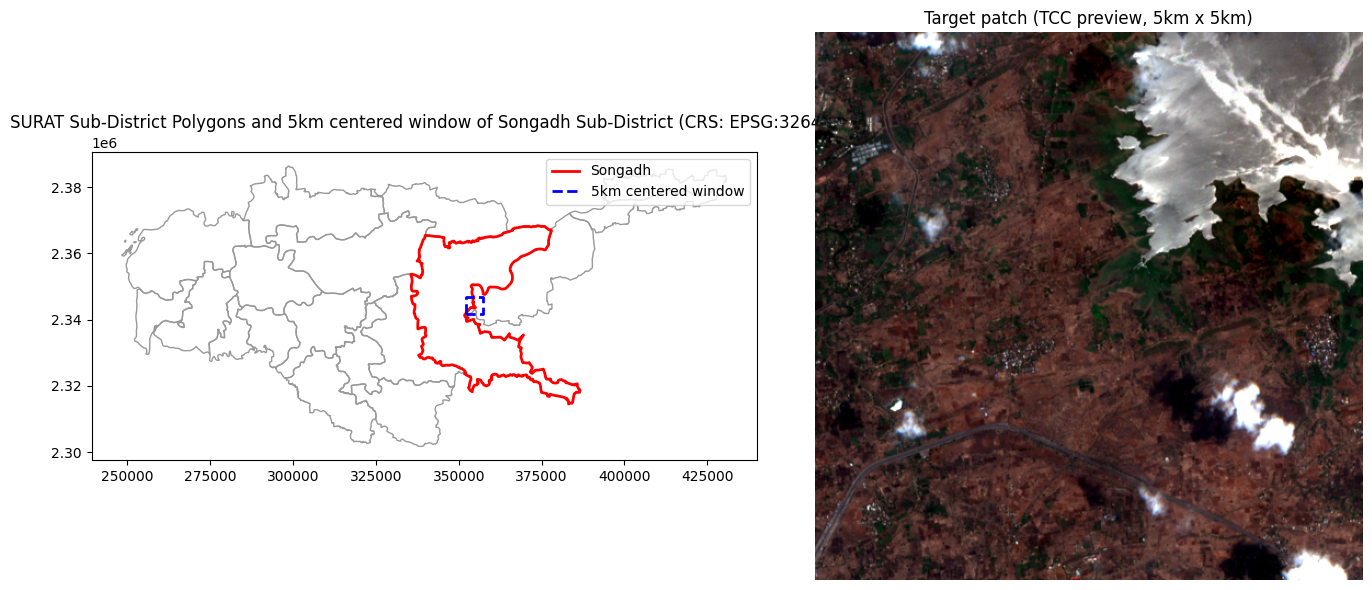

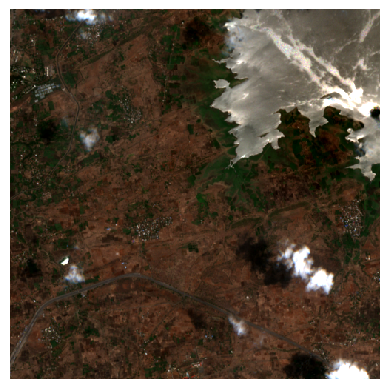

<Figure size 640x480 with 0 Axes>

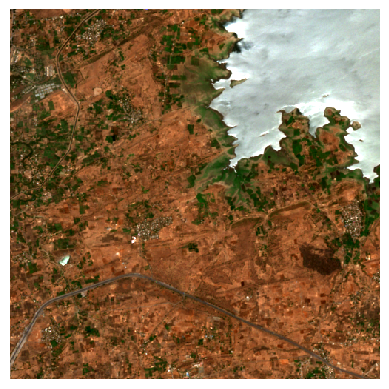

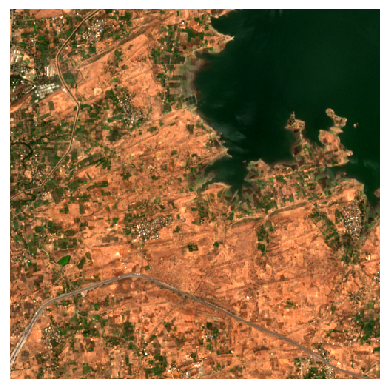

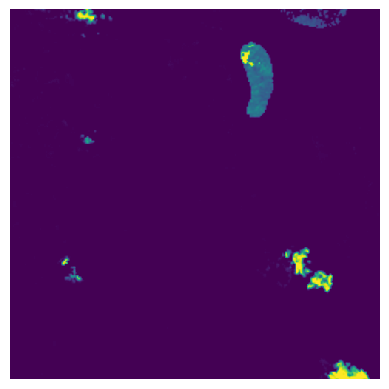

Saved 5km patch GeoTIFF: /content/_SD_PATCH/Songadh_SAFE-PATCH-5000meter.tif


In [ ]:
# [G-1A]. Data Loading and Visualization of Windowed Patches and Cloud Mask
# This section focuses on loading a specific 256x256 pixel patch from the satellite imagery
# using offsets to define the window. It also loads a corresponding cloud mask.
# Finally, it visualizes the windowed target, features, and the cloud mask.

# --- Optional: Windowed data loading (commented out) AUTHOR SAMPLE EXAMPLE: WORDPRESS---
# 256 x 256 patch
## y_size = 512
## x_size = 512
# Offsets to just read at the top-right of the image
## y_offset = 0
## x_offset = 0

# Perform the windowed data loading
## target = load_product_windowed(target_path, y_size, x_size, y_offset, x_offset)
## features = load_product_windowed(features_path, y_size, x_size, y_offset, x_offset)

# Also load a cloud mask included in the data product
## mask = load_product_windowed(target_path, y_size, x_size, y_offset, x_offset, keep_bands=["CLD"], bands_20m={"CLD":0})[:,:,0]

# [G-1B] extract a 5 km x 5 km patch centered on Any District centroid (10 m grid),
# load multi-resolution bands with a fixed loader,
# visualise shapefile + computed square patch and TCC preview,
# call VPint2 visualisers, and optionally save the patch.
#

!pip install geopandas # Install geopandas if not already installed

import os
import math
import warnings
from pathlib import Path
import numpy as np
import rasterio
from rasterio.windows import from_bounds, Window
from rasterio.enums import Resampling
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from matplotlib.lines import Line2D
from rasterio.transform import Affine

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=rasterio.errors.NotGeoreferencedWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# === User configuration (EDIT THESE PATHS) ===
target_path = "/content/drive/MyDrive/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip"
# CLOUD-FREE TARGET image
target_ref_path = "/content/drive/MyDrive/EarthLens/Assignment-II/DATASET/SURAT/Target_Image/S2C_MSIL2A_20250501T053701_N0511_R005_T43QCD_20250501T102217.SAFE.zip"
features_path = "/content/drive/MyDrive/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.zip"
shapefile = "/content/drive/MyDrive/EarthLens/Assignment-II/DATASET/SURAT/SHP/SUB_DISTR/surat_sd.shp"
target_name = selected_sub_district               # subdistrict to center the patch on
name_field = "Sub_Distri"           # attribute field in shapefile
patch_size_m = 5000                 # patch side length in meters (5 km)
out_patch_tif = f"/content/_SD_PATCH/{selected_sub_district}_SAFE-PATCH-{patch_size_m}meter.tif"   # optional save path for inspection

# Create output directories
os.makedirs("/content/_SD_PATCH/", exist_ok=True)

# keep_bands and band maps (match EO_utils defaults)
keep_bands = ["B1","B2","B3","B4","B5","B6","B7","B8","B8A","B9","B11","B12"]
bands_10m = {"B2":1, "B3":2, "B4":3, "B8":7}
bands_20m = {"B5":4, "B6":5, "B7":6, "B8A":8, "B11":10, "B12":11, "CLD":12}
bands_60m = {"B1":0, "B9":9}

# --- Import VPint utilities (visualisers) ---
from VPint.utils.EO_utils import normalise_and_visualise, normalise_and_visualise_single

# --- Fixed loader (correct res_window calculation) ---
def load_product_windowed_fixed(path, y_size, x_size, y_offset, x_offset,
                                keep_bands=keep_bands,
                                bands_10m=bands_10m,
                                bands_20m=bands_20m,
                                bands_60m=bands_60m):
    """
    Reads SAFE ZIP subdatasets and resamples 20m/60m bands into the 10m output grid.
    Returns array shaped (y_size, x_size, nbands) dtype uint16.
    """
    import rasterio
    from rasterio.windows import Window
    grid = np.zeros((y_size, x_size, len(keep_bands))).astype(np.uint16)

    with rasterio.open(path) as raw_product:
        product = raw_product.subdatasets
    if not product:
        raise RuntimeError("SAFE ZIP contains no subdatasets.")

    resolution_index = 0
    scales = [bands_10m, bands_20m, bands_60m, {}]

    for bs in product:
        with rasterio.open(bs, dtype="uint16") as bandset:
            desc = bandset.descriptions or []
            size_y_local = bandset.profile['height']
            size_x_local = bandset.profile['width']

            band_index = 1
            for d in desc:
                band_name = d.split(",")[0]
                if (band_name in keep_bands) and (band_name in scales[resolution_index]):
                    if band_name in bands_10m:
                        b = bands_10m[band_name]
                        upscale_factor = 1
                    elif band_name in bands_20m:
                        b = bands_20m[band_name]
                        upscale_factor = 2
                    elif band_name in bands_60m:
                        b = bands_60m[band_name]
                        upscale_factor = 6
                    else:
                        band_index += 1
                        continue

                    window = Window(x_offset, y_offset, x_size, y_size)

                    # compute local-resolution window correctly (divide offsets/sizes by upscale_factor)
                    res_col_off = x_offset / upscale_factor
                    res_row_off = y_offset / upscale_factor
                    res_width = window.width / upscale_factor
                    res_height = window.height / upscale_factor
                    res_window = Window(res_col_off, res_row_off, res_width, res_height)

                    try:
                        band_values = bandset.read(
                            band_index,
                            out_shape=(int(window.height), int(window.width)),
                            resampling=Resampling.bilinear,
                            window=res_window
                        )
                    except Exception:
                        # fallback: clamp integer window and retry
                        col0 = int(max(0, math.floor(res_window.col_off)))
                        row0 = int(max(0, math.floor(res_window.row_off)))
                        w = int(max(1, min(size_x_local - col0, math.ceil(res_window.width))))
                        h = int(max(1, min(size_y_local - row0, math.ceil(res_window.height))))
                        res_window2 = Window(col0, row0, w, h)
                        band_values = bandset.read(
                            band_index,
                            out_shape=(int(window.height), int(window.width)),
                            resampling=Resampling.bilinear,
                            window=res_window2
                        )

                    grid[:, :, b] = band_values
                band_index += 1
        resolution_index += 1

    return grid

# --- Load shapefile and select sUB District polygon ---
gdf = gpd.read_file(shapefile)
if gdf is None or gdf.empty:
    raise RuntimeError("Shapefile could not be read or is empty. Check shapefile path.")
gdf[name_field] = gdf[name_field].astype(str).str.strip()
row = gdf[gdf[name_field].str.lower() == target_name.lower()]
if row.empty:
    raise ValueError(f"Target '{target_name}' not found in shapefile attribute '{name_field}'. Available: {list(gdf[name_field].unique())[:20]}")
geom = row.geometry.iloc[0]

# --- Find a proper 10m JP2 subdataset inside the SAFE ZIP ---
with rasterio.open(target_path) as z:
    subds = z.subdatasets
    if not subds:
        raise RuntimeError("SAFE ZIP contains no subdatasets.")
    sd_10m = None
    for sd in subds:
        sd_lower = sd.lower()
        if (".jp2" in sd_lower) and ("b02" in sd_lower or "b03" in sd_lower or "b04" in sd_lower):
            sd_10m = sd
            break
    if sd_10m is None:
        for sd in subds:
            if ".jp2" in sd.lower():
                sd_10m = sd
                break
    if sd_10m is None:
        for sd in subds:
            if ":10m:" in sd and "mtd_msil2a.xml" not in sd.lower():
                sd_10m = sd
                break
    if sd_10m is None:
        sd_10m = subds[0]
        warnings.warn("Could not find a JP2 10m subdataset; using first subdataset. If it lacks geotransform, reads may fail.")

# Validate geotransform presence
with rasterio.open(sd_10m) as ref_test:
    if ref_test.transform is None or ref_test.transform == rasterio.Affine.identity():
        # try to find any georeferenced JP2
        found = False
        for sd in subds:
            if ".jp2" in sd.lower():
                with rasterio.open(sd) as r2:
                    if r2.transform is not None and r2.transform != rasterio.Affine.identity():
                        sd_10m = sd
                        found = True
                        break
        if not found:
            raise RuntimeError("No georeferenced JP2 subdataset found in SAFE ZIP. Cannot compute 10m window.")

# --- Open 10m reference to get CRS and dimensions ---
with rasterio.open(sd_10m) as ref:
    ref_crs = ref.crs
    ref_transform = ref.transform
    ref_width = ref.width
    ref_height = ref.height

# Reproject polygon to reference CRS if needed
if gdf.crs is None:
    raise RuntimeError("Shapefile has no CRS. Ensure .prj exists or set CRS before running.")
if gdf.crs != ref_crs:
    geom = gpd.GeoSeries([geom], crs=gdf.crs).to_crs(ref_crs).iloc[0]

# --- Compute pixel window centered on Sub District centroid for a square patch of patch_size_m x patch_size_m ---
# For 10 m grid, pixels_per_meter = 1 / 10 => pixels_per_side = patch_size_m / 10
pixels_per_side = int(round(patch_size_m / 10.0))
if pixels_per_side <= 0:
    raise ValueError("patch_size_m must be positive and >= 10.")

half_pixels = pixels_per_side // 2

# centroid in CRS units
centroid = geom.centroid
centroid_x, centroid_y = centroid.x, centroid.y

# convert centroid to pixel indices (row, col)
with rasterio.open(sd_10m) as ref:
    row_c, col_c = ref.index(centroid_x, centroid_y)  # returns (row, col)

# build centered window and clamp to image bounds
row_off = int(row_c - half_pixels)
col_off = int(col_c - half_pixels)
# ensure within bounds
row_off = max(0, min(row_off, ref_height - pixels_per_side))
col_off = max(0, min(col_off, ref_width - pixels_per_side))

y_offset = row_off
x_offset = col_off
y_size = pixels_per_side
x_size = pixels_per_side

# Final validation
if (y_offset + y_size) > ref_height:
    y_size = ref_height - y_offset
if (x_offset + x_size) > ref_width:
    x_size = ref_width - x_offset
if y_size <= 0 or x_size <= 0:
    raise RuntimeError("Computed centered window is out of bounds or has non-positive size.")

print("Centered 5km window (10m grid):", {"y_offset": y_offset, "x_offset": x_offset, "y_size": y_size, "x_size": x_size})
print("Using 10m reference subdataset:", sd_10m.split("|")[-1])

# --- Build a polygon for the computed window in CRS coordinates (for plotting) ---
with rasterio.open(sd_10m) as ref:
    window = Window(x_offset, y_offset, x_size, y_size)
    window_transform = ref.window_transform(window)
    x_min, y_max = window_transform * (0, 0)
    x_max, y_min = window_transform * (x_size, y_size)
    window_geom = box(x_min, y_min, x_max, y_max)

# --- Calculate PATCH_pred_affine and crs for K and M sections ---
# These will be the global variables needed by sections K and M
# Define the output affine transform for the 20m GSD GeoTIFF for this 5km patch.
# The pred array from VPint2 will be 500x500 (representing 5km @ 10m). When saved
# at 20m, its dimensions will be 250x250. The transform must reflect this 20m pixel size.

# Calculate target output pixel dimensions for a 5km x 5km area at 20m resolution
output_pixel_width_20m = int(round((x_max - x_min) / 20.0))
output_pixel_height_20m = int(round((y_max - y_min) / 20.0))

# Ensure calculated output dimensions are as expected (250x250 for 5km at 20m)
if output_pixel_width_20m != 250 or output_pixel_height_20m != 250:
    warnings.warn(f"Expected 250x250 for 5km patch at 20m, but got ({output_pixel_width_20m}x{output_pixel_height_20m}). Check calculations.")

# The CRS is already extracted above
global PATCH_pred_affine

# The pred_affine for a 20m GeoTIFF of this 5km patch
PATCH_pred_affine = Affine(20.0, 0.0, x_min, 0.0, -20.0, y_max)

print("\nParameters for 20m GeoTIFF (for sections K and M):")
print(f"  CRS: {original_crs}")
print(f"  Pred Affine:\n{PATCH_pred_affine}")


# --- Visualise shapefile, Sub District polygon and computed window rectangle ---
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Left: shapefile overview with Sub District and window
try:
    gdf_plot = gdf.to_crs(ref_crs)
    gdf_plot.plot(ax=ax[0], facecolor="none", edgecolor="#999999")
    row_plot = row.to_crs(ref_crs)
    row_plot.plot(ax=ax[0], facecolor="none", edgecolor="red", linewidth=2)
    gpd.GeoSeries([window_geom], crs=ref_crs).plot(ax=ax[0], facecolor="none", edgecolor="blue", linewidth=2, linestyle="--")
    ax[0].set_title(f"TAPI-SURAT Sub-District Polygons and 5km centered window of {target_name} Sub-District (CRS: {ref_crs})")
    handles = [
        Line2D([0], [0], color="red", lw=2, label=target_name),
        Line2D([0], [0], color="blue", lw=2, linestyle="--", label="5km centered window"),
    ]
    ax[0].legend(handles=handles)
except Exception as e:
    ax[0].text(0.5, 0.5, f"Failed to plot shapefile:\n{e}", ha="center")
    ax[0].axis("off")

# Right: TCC preview of the target SAFE patch (if load succeeds)
target = None
try:
    target = load_product_windowed_fixed(
        target_path,
        y_size=y_size,
        x_size=x_size,
        y_offset=y_offset,
        x_offset=x_offset,
        keep_bands=keep_bands,
        bands_10m=bands_10m,
        bands_20m=bands_20m,
        bands_60m=bands_60m
    )
    # find indices of B2,B3,B4 in keep_bands
    b2_idx = keep_bands.index("B2") if "B2" in keep_bands else None
    b3_idx = keep_bands.index("B3") if "B3" in keep_bands else None
    b4_idx = keep_bands.index("B4") if "B4" in keep_bands else None

    def stretch_uint8(band, low=2, high=98):
        valid = band[np.isfinite(band)]
        if valid.size == 0:
            return np.zeros_like(band, dtype=np.uint8)
        lo = float(np.nanpercentile(valid, low))
        hi = float(np.nanpercentile(valid, high))
        if hi == lo:
            scaled = np.clip(band, 0, 255)
        else:
            scaled = (band - lo) / (hi - lo)
        return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)

    if None not in (b2_idx, b3_idx, b4_idx):
        r = stretch_uint8(target[:, :, b4_idx])
        g = stretch_uint8(target[:, :, b3_idx])
        b = stretch_uint8(target[:, :, b2_idx])
        rgb = np.dstack([r, g, b])
        ax[1].imshow(rgb)
        ax[1].set_title("Target patch (TCC preview, 5km x 5km)")
        ax[1].axis("off")
    else:
        ax[1].text(0.5, 0.5, "B2/B3/B4 not found in keep_bands", ha="center")
        ax[1].axis("off")
except Exception as e:
    ax[1].text(0.5, 0.5, f"Failed to load patch:\n{e}", ha="center")
    ax[1].axis("off")

plt.tight_layout()
plt.show()

# --- Also visualise using VPint2 normalise_and_visualise if available ---
try:
    if target is not None:
        normalise_and_visualise(target)
except Exception:
    pass

################################################################################
# For the CLOUD-FREE TARGET IMAGE:
# Right: TCC preview of the target_ref SAFE patch (if load succeeds)
target_ref = None
try:
    target_ref = load_product_windowed_fixed(
        target_ref_path,
        y_size=y_size,
        x_size=x_size,
        y_offset=y_offset,
        x_offset=x_offset,
        keep_bands=keep_bands,
        bands_10m=bands_10m,
        bands_20m=bands_20m,
        bands_60m=bands_60m
    )
    # Find indices of B2, B3, B4 in keep_bands
    b2_idx = keep_bands.index("B2") if "B2" in keep_bands else None
    b3_idx = keep_bands.index("B3") if "B3" in keep_bands else None
    b4_idx = keep_bands.index("B4") if "B4" in keep_bands else None

    def stretch_uint8(band, low=2, high=98):
        valid = band[np.isfinite(band)]
        if valid.size == 0:
            return np.zeros_like(band, dtype=np.uint8)
        lo = float(np.nanpercentile(valid, low))
        hi = float(np.nanpercentile(valid, high))
        if hi == lo:
            scaled = np.clip(band, 0, 255)
        else:
            scaled = (band - lo) / (hi - lo)
        return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)

    if None not in (b2_idx, b3_idx, b4_idx):
        r = stretch_uint8(target_ref[:, :, b4_idx])
        g = stretch_uint8(target_ref[:, :, b3_idx])
        b = stretch_uint8(target_ref[:, :, b2_idx])
        rgb = np.dstack([r, g, b])
        ax[1].imshow(rgb)
        ax[1].set_title("CLOUD-FREE Target patch (TCC preview, 5km x 5km)")
        ax[1].axis("off")
    else:
        ax[1].text(0.5, 0.5, "B2/B3/B4 not found in keep_bands", ha="center")
        ax[1].axis("off")
except Exception as e:
    ax[1].text(0.5, 0.5, f"Failed to load patch:\n{e}", ha="center")
    ax[1].axis("off")

plt.tight_layout()
plt.show()

# Also visualise using VPint2 normalise_and_visualise if available
try:
    if target_ref is not None:
        normalise_and_visualise(target_ref)
except Exception:
    pass
################################################################################

# --- Load features and mask using fixed loader and visualise with VPint2 functions ---
try:
    features = load_product_windowed_fixed(
        features_path,
        y_size=y_size,
        x_size=x_size,
        y_offset=y_offset,
        x_offset=x_offset,
        keep_bands=keep_bands,
        bands_10m=bands_10m,
        bands_20m=bands_20m,
        bands_60m=bands_60m
    )
    cloud_mask_grid = load_product_windowed_fixed(
        target_path,
        y_size=y_size,
        x_size=x_size,
        y_offset=y_offset,
        x_offset=x_offset,
        keep_bands=["CLD"],
        bands_10m={},
        bands_20m={"CLD":0},
        bands_60m={}
    )
    mask = cloud_mask_grid[:, :, 0]
    try:
        normalise_and_visualise(features)
    except Exception:
        pass
    try:
        normalise_and_visualise_single(mask, percentile_clip=False)
    except Exception:
        pass
except Exception as e:
    print("Failed to load features/mask:", e)

# --- Optional: save the returned target patch as a GeoTIFF for inspection ---
try:
    if target is not None:
        os.makedirs(os.path.dirname(out_patch_tif), exist_ok=True) # Create the directory if it doesn't exist
        with rasterio.open(sd_10m) as ref:
            window = Window(x_offset, y_offset, x_size, y_size)
            window_transform = ref.window_transform(window)
            out_meta = ref.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": int(y_size),
                "width": int(x_size),
                "count": target.shape[2],
                "transform": window_transform,
                "dtype": target.dtype,
                "compress": "lzw"
            })
        arr_to_write = np.transpose(target, (2, 0, 1))
        with rasterio.open(out_patch_tif, "w", **out_meta) as dst:
            for i in range(arr_to_write.shape[0]):
                dst.write(arr_to_write[i].astype(target.dtype), i+1)
        print("Saved 5km patch GeoTIFF:", out_patch_tif)
except Exception:
    pass


# ---------------------------------------------------------
# ---------------------------------------------------------

# [G-2]. Data Loading and Visualization of Entire Scene and Cloud Mask
# This section focuses on loading the entire satellite imagery scene.
# It loads the full target, features, and corresponding cloud mask.
# Finally, it visualizes the target, features, and the cloud mask.

# --- Active: Full scene data loading ---
# Perform the full scene data loading
# target = load_product(target_path) # already assigned in previous section F
# features = load_product(features_path) # already assigned in previous section F

# Also load a cloud mask included in the data product for the entire scene
#Uncomment### mask = load_product(target_path, keep_bands=["CLD"], bands_20m={"CLD":0})[:,:,0]
# ---------------------------------------

# Visualise
#Uncomment### normalise_and_visualise(target)
#Uncomment### normalise_and_visualise(features)
#Uncomment### normalise_and_visualise_single(mask, percentile_clip=False)

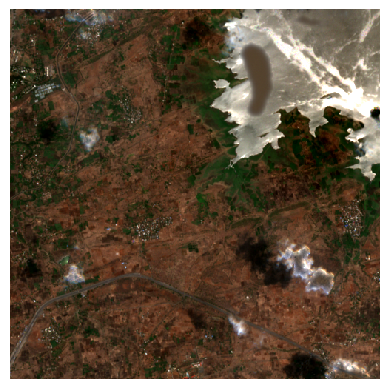

In [ ]:
# [H]. VPint2 Interpolation and Visualization
# This section performs the core interpolation using the VPint2_interpolator.
# It initializes the interpolator with the target, features, and cloud mask data.
# After running the interpolation, it visualizes the generated 'pred' (predicted) image.
VPint2 = VPint2_interpolator(target, features, mask=mask, bands_first=False, threshold=10) # Set bands_first to True if your data is C x H x W instead of H x W x C

# ORIGINAL IN CODE
pred = VPint2.run()
# pred = VPint2.run(resistance=True, prioritise_identity=True, clip_val=10000,
                    #auto_adapt=True, auto_adaptation_epochs=10, auto_adaptation_max_iter=100, auto_adaptation_strategy='random', auto_adaptation_proportion=0.8)


normalise_and_visualise(pred)

/usr/local/lib/python3.12/dist-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


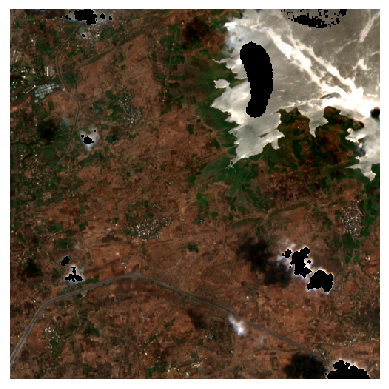

In [ ]:
# [I]. Displaying the target of the VPint2 Interpolator
# This section initializes the VPint2_interpolator again (or uses a previously initialized one).
# It then visualizes the 'target' data that was passed to the interpolator.
# This 'target' represents the input image *after* the cloud mask has been applied,
# indicating the areas that VPint2 will attempt to interpolate to remove cloud cover,

VPint2 = VPint2_interpolator(target, features, mask=mask, bands_first=False, threshold=10)
normalise_and_visualise(VPint2.target)

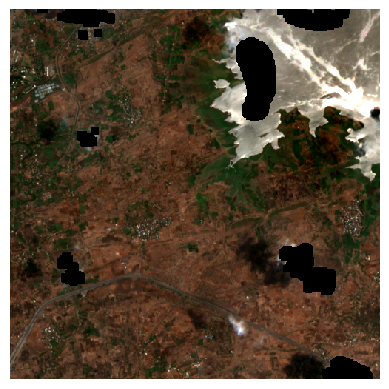

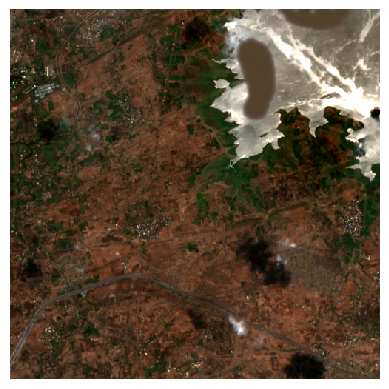

In [ ]:
# [J]. VPint2 Interpolation with Buffered Mask
# This section demonstrates VPint2 interpolation with a buffered cloud mask.
# The 'buffer_mask=True' argument applies a buffer around the original mask,
# expanding the masked area (e.g., to account for cloud shadows or partial clouds),
# which can improve the interpolation quality as discussed in the referenced blog post (https://adaresearch.wordpress.com/2024/08/07/vpint2_cloud_removal/).
# 'mask_buffer_size' controls the extent of this buffer.
# After buffering, the modified target (VPint2.target) is visualized,
# and then the VPint2 algorithm is run to produce the interpolated 'pred' image,
# which is also visualized.
VPint2 = VPint2_interpolator(target, features, mask=mask, buffer_mask=True, mask_buffer_size=5, bands_first=False, threshold=10)
normalise_and_visualise(VPint2.target) # Visualise the buffered mask
pred = VPint2.run() # Run the algorithm

normalise_and_visualise(pred)

In [ ]:
print(f"Original Transform: {original_transform}")
print(f"Original CRS: {original_crs}")
print(product_subdatasets[0])

Original Transform: | 10.00, 0.00, 300000.00|
| 0.00,-10.00, 2400000.00|
| 0.00, 0.00, 1.00|
Original CRS: EPSG:32643
SENTINEL2_L2A:/vsizip//content/drive/MyDrive/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.SAFE/MTD_MSIL2A.xml:10m:EPSG_32643


In [ ]:
# [K]. Save Interpolated Image as GeoTIFF
# This section saves the generated interpolated image (`pred`) as a GeoTIFF file to Google Drive.
# It uses the `rasterio` library for GeoTIFF creation.
# The georeferencing is now correctly derived from the 5km x 5km patch at 20m resolution.

import rasterio
import os
import numpy as np
from rasterio.transform import Affine
from google.colab import files

# Define output directory and file path in Google Drive
output_dir = "/content/drive/MyDrive/EarthLens/Assignment-II/VPint2_OP/"
os.makedirs(output_dir, exist_ok=True)
output_filepath = os.path.join(output_dir, f"VPint2_InPolated_Manual_SURAT-{selected_sub_district}-PATCH-{patch_size_m}meter_T43QCD_20250513T090819.tif")

# The 'pred' array is in HWC (Height, Width, Channel) format
# Rasterio expects CWH (Channel, Height, Width) format for writing
pred_cwh = pred.transpose(2, 0, 1)

# Get image dimensions and data type from the transposed array
count, height, width = pred_cwh.shape
dtype = pred_cwh.dtype

#--------#
# OPTION A - USE TRANSFORM PARAMETERS FROM ORIGINAL WHOLE TILE
# Use the extracted original transform and CRS for georeferencing
# Fallback to default if not found (though it should be found now)
## transform_to_use = original_transform if original_transform is not None else Affine(1, 0, 0, 0, -1, 0)
## crs_to_use = original_crs if original_crs is not None else None # Keep None if no original CRS found

# IMPORTANT: Scale the transform to match the 20m resolution of the 'pred' array.
# The 'original_transform' was extracted from a 10m band. Since 'pred' is 20m,
# the pixel size in the transform needs to be doubled.
## if transform_to_use is not None:
##     transform_to_use = transform_to_use * Affine.scale(2, 2)

#--------#
# OPTION B - USE TRANSFORM PARAMETERS FROM PATCH
# Use the already computed PATCH_pred_affine and crs from cell _s0k9eswbM_N
# These now correctly reflect the 5km x 5km patch at 20m resolution.
transform_to_use = PATCH_pred_affine
crs_to_use = original_crs

# The transform is already scaled for 20m, so no further scaling is needed here.
if transform_to_use is not None:
     transform_to_use = transform_to_use * Affine.scale(1/2, 1/2)

# Save the interpolated image as a GeoTIFF
with rasterio.open(
    output_filepath,
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=count,
    dtype=dtype,
    crs=crs_to_use,
    transform=transform_to_use
) as dst:
    dst.write(pred_cwh)

print(f"Interpolated image saved to: {output_filepath}")

# Provide an option to download the file directly
print("\nTo download the file directly to your local machine, execute the following command in a new cell:")
print(f"files.download('{output_filepath}')")

Interpolated image saved to: /content/drive/MyDrive/EarthLens/Assignment-II/VPint2_OP/VPint2_InPolated_Manual_SURAT-Songadh-PATCH-5000meter_T43QCD_20250513T090819.tif

To download the file directly to your local machine, execute the following command in a new cell:
files.download('/content/drive/MyDrive/EarthLens/Assignment-II/VPint2_OP/VPint2_InPolated_Manual_SURAT-Songadh-PATCH-5000meter_T43QCD_20250513T090819.tif')


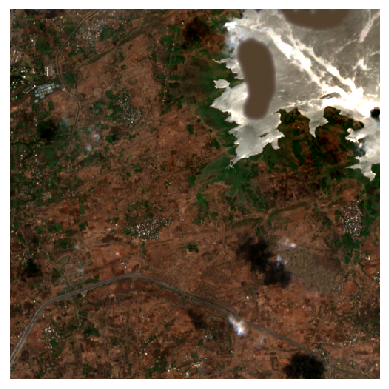

In [ ]:
# [L]. Advanced VPint2 Interpolation with Auto-Adaptation
# This section demonstrates an advanced application of the VPint2_interpolator.
# It initializes the interpolator with a buffered mask (`buffer_mask=True`) to account for surrounding cloud effects.
# The interpolation algorithm is then run with automatically configured extensions, as discussed in the VPint2 cloud removal blog post (https://adaresearch.wordpress.com/2024/08/07/vpint2_cloud_removal/).
# Key parameters used include `resistance=True`, `prioritise_identity=True`, and `clip_val=10000`.
# Furthermore, `auto_adapt=True` is enabled with specific `auto_adaptation_epochs`, `auto_adaptation_max_iter`,
# `auto_adaptation_strategy`, and `auto_adaptation_proportion` to dynamically optimize the interpolation process
# for improved results, especially in complex cloud scenarios.
VPint2 = VPint2_interpolator(target, features, mask=mask, buffer_mask=True, mask_buffer_size=5, bands_first=False, threshold=10)

# Run the algorithm with automatically configured extensions
pred = VPint2.run(resistance=True, prioritise_identity=True, clip_val=10000,
                    auto_adapt=True, auto_adaptation_epochs=10, auto_adaptation_max_iter=100, auto_adaptation_strategy='random', auto_adaptation_proportion=0.8)

normalise_and_visualise(pred)


In [ ]:
# [M]. Save Interpolated Image as GeoTIFF
# This section saves the generated interpolated image (`pred`) as a GeoTIFF file to Google Drive.
# It uses the `rasterio` library for GeoTIFF creation.
# The georeferencing is now correctly derived from the 5km x 5km patch at 20m resolution.

import rasterio
import os
import numpy as np
from rasterio.transform import Affine
from google.colab import files

# Define output directory and file path in Google Drive
output_dir = "/content/drive/MyDrive/EarthLens/Assignment-II/VPint2_OP/"
os.makedirs(output_dir, exist_ok=True)
output_filepath = os.path.join(output_dir, f"VPint2_InPolated_AutoAdap_SURAT-{selected_sub_district}-PATCH-{patch_size_m}meter_T43QCD_20250513T090819.tif")

# The 'pred' array is in HWC (Height, Width, Channel) format
# Rasterio expects CWH (Channel, Height, Width) format for writing
pred_cwh = pred.transpose(2, 0, 1)

# Get image dimensions and data type from the transposed array
count, height, width = pred_cwh.shape
dtype = pred_cwh.dtype

#--------#
# OPTION A - USE TRANSFORM PARAMETERS FROM ORIGINAL WHOLE TILE
# Use the extracted original transform and CRS for georeferencing
# Fallback to default if not found (though it should be found now)
## transform_to_use = original_transform if original_transform is not None else Affine(1, 0, 0, 0, -1, 0)
## crs_to_use = original_crs if original_crs is not None else None # Keep None if no original CRS found

# IMPORTANT: Scale the transform to match the 20m resolution of the 'pred' array.
# The 'original_transform' was extracted from a 10m band. Since 'pred' is 20m,
# the pixel size in the transform needs to be doubled.
## if transform_to_use is not None:
##     transform_to_use = transform_to_use * Affine.scale(2, 2)

#--------#
# OPTION B - USE TRANSFORM PARAMETERS FROM PATCH
# Use the already computed PATCH_pred_affine and crs from cell _s0k9eswbM_N
# These now correctly reflect the 5km x 5km patch at 20m resolution.
transform_to_use = PATCH_pred_affine
crs_to_use = original_crs

# The transform is already scaled for 20m, so no further scaling is needed here.
if transform_to_use is not None:
     transform_to_use = transform_to_use * Affine.scale(1/2, 1/2)

# Save the interpolated image as a GeoTIFF
with rasterio.open(
    output_filepath,
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=count,
    dtype=dtype,
    crs=crs_to_use,
    transform=transform_to_use
) as dst:
    dst.write(pred_cwh)

print(f"Interpolated image saved to: {output_filepath}")

# Provide an option to download the file directly
print("\nTo download the file directly to your local machine, execute the following command in a new cell:")
print(f"files.download('{output_filepath}')")

Interpolated image saved to: /content/drive/MyDrive/EarthLens/Assignment-II/VPint2_OP/VPint2_InPolated_AutoAdap_SURAT-Songadh-PATCH-5000meter_T43QCD_20250513T090819.tif

To download the file directly to your local machine, execute the following command in a new cell:
files.download('/content/drive/MyDrive/EarthLens/Assignment-II/VPint2_OP/VPint2_InPolated_AutoAdap_SURAT-Songadh-PATCH-5000meter_T43QCD_20250513T090819.tif')


In [ ]:
# [N]. display two visualization rows (each row: target, features, pred/exported TIFF)
# Row 1: target (cloudy), features (reference), pred (in-memory VPint2 output)
# Row 2: target, features, exported GeoTIFF file (on Drive)
#
# Assumptions:
# - `target` and `features` are numpy arrays in memory shaped (H, W, C) or (H, W, bands) as returned by
#   load_product_windowed_fixed (which returns (y, x, bands)).
# - `pred` is the VPint2 output in memory in HWC format (Height, Width, Channels).
# - If any of these are missing, the code will try to load `target`/`features` from an optional saved patch TIFF.
# - Edit `exported_tif_path` to point to the GeoTIFF you exported to Drive.
#

import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# === User-editable path to the exported GeoTIFF (change if needed) ===
exported_tif_path = f"/content/drive/MyDrive/EarthLens/Assignment-II/VPint2_OP/VPint2_InPolated_AutoAdap_SURAT-{selected_sub_district}-PATCH-{patch_size_m}meter_T43QCD_20250513T090819.tif"

# === Helper utilities (fixed bug) ===
def ensure_hwc(arr):
    """Return array in HWC format (H, W, C). Accepts (H,W,C) or (C,H,W) or (H,W)."""
    if arr is None:
        return None
    arr = np.asarray(arr)
    if arr.ndim == 2:
        return arr[..., None]
    if arr.ndim == 3:
        # Heuristic: if first dim is small and equals typical channel counts, treat as (C,H,W)
        c0, d1, d2 = arr.shape
        if c0 <= 4 and d1 > 1 and d2 > 1 and c0 != d2:
            # likely (C,H,W) -> convert
            return np.transpose(arr, (1, 2, 0))
        return arr
    raise ValueError("Unsupported array shape: " + str(arr.shape))

def percentile_stretch_uint8(band, low=2, high=98):
    """Stretch single band to uint8 using percentiles (ignores NaNs). Fixed variable usage."""
    band_arr = np.asarray(band).astype(np.float32)
    valid = band_arr[np.isfinite(band_arr)]
    if valid.size == 0:
        return np.zeros_like(band_arr, dtype=np.uint8)
    lo = float(np.nanpercentile(valid, low))
    hi = float(np.nanpercentile(valid, high))
    if hi == lo:
        scaled = np.clip(band_arr, 0, 255)
    else:
        scaled = (band_arr - lo) / (hi - lo)
    return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)

def make_tcc_from_grid(grid, keep_bands=None):
    """
    Given grid in HWC with many bands (or fewer), attempt to build a TCC (B04,B03,B02).
    If keep_bands is provided (list of band names in order), it will look up indices for B2,B3,B4.
    Returns uint8 RGB image (H,W,3) or None if impossible.
    """
    if grid is None:
        return None
    g = ensure_hwc(grid)
    h, w, c = g.shape
    # If keep_bands provided, find indices
    if keep_bands is not None:
        try:
            b2 = keep_bands.index("B2")
            b3 = keep_bands.index("B3")
            b4 = keep_bands.index("B4")
            bands = (b4, b3, b2)  # R,G,B order
            if max(bands) < c:
                r = percentile_stretch_uint8(g[..., bands[0]])
                gg = percentile_stretch_uint8(g[..., bands[1]])
                b = percentile_stretch_uint8(g[..., bands[2]])
                return np.dstack([r, gg, b])
        except ValueError:
            pass
    # Fallback heuristics:
    if c >= 3:
        # assume channels are in B2,B3,B4 order (B,G,R) -> reorder to R,G,B
        r = percentile_stretch_uint8(g[..., min(2, c-1)])
        gg = percentile_stretch_uint8(g[..., min(1, c-1)])
        b = percentile_stretch_uint8(g[..., 0])
        return np.dstack([r, gg, b])
    if c == 1:
        gray = percentile_stretch_uint8(g[..., 0])
        return np.dstack([gray, gray, gray])
    return None

# === Prepare arrays: target, features, pred ===
# If these variables are already in the notebook, use them. Otherwise try to load from saved patch TIFFs.
try:
    _ = target  # noqa: F821
except NameError:
    target = None

try:
    _ = target_ref  # noqa: F821
except NameError:
    target_ref = None

try:
    _ = features  # noqa: F821
except NameError:
    features = None

try:
    _ = pred  # noqa: F821
except NameError:
    pred = None

# If target or features missing, try to load from a saved patch file (adjust filenames if needed)
def try_load_patch(path):
    if not path or not os.path.exists(path):
        return None
    with rasterio.open(path) as src:
        arr = src.read()  # (bands, H, W)
        arr = np.transpose(arr, (1, 2, 0))  # to HWC
    return arr

# Provide your actual saved filenames here if different
fallback_patch_candidates = [
    "./SubDist_5km_PATCH.tif",
    "/content/_SD_PATCH/SubDist_5km_PATCH.tif",
    f"/content/_SD_PATCH/{selected_sub_district}_SAFE-PATCH-{patch_size_m}meter.tif"
]

for p in fallback_patch_candidates:
     if (target is None or target_ref is None or features is None) and p:
        arr = try_load_patch(p)
        if arr is not None:
            if target is None:
                target = arr.copy()
            if target_ref is None:
                target_ref = arr.copy()
            if features is None:
                features = arr.copy()

# === Build TCC images ===
keep_bands_local = globals().get("keep_bands", None)

tcc_target = make_tcc_from_grid(target, keep_bands=keep_bands_local)
tcc_target_ref = make_tcc_from_grid(target_ref, keep_bands=keep_bands_local)
tcc_features = make_tcc_from_grid(features, keep_bands=keep_bands_local)
tcc_pred = None

# pred may be HWC already; ensure and convert to uint8 for display
if pred is not None:
    pred_hwc = ensure_hwc(pred)
    if pred_hwc.shape[2] == 3:
        if pred_hwc.dtype == np.uint8:
            tcc_pred = pred_hwc
        else:
            chs = [percentile_stretch_uint8(pred_hwc[..., i]) for i in range(3)]
            tcc_pred = np.dstack(chs)
    else:
        tcc_pred = make_tcc_from_grid(pred_hwc, keep_bands=keep_bands_local)
        if tcc_pred is None and pred_hwc.shape[2] >= 3:
            chs = [percentile_stretch_uint8(pred_hwc[..., i]) for i in range(3)]
            # attempt reorder if channels are B,G,R
            tcc_pred = np.dstack([chs[2], chs[1], chs[0]])
        elif tcc_pred is None:
            ch = percentile_stretch_uint8(pred_hwc[..., 0])
            tcc_pred = np.dstack([ch, ch, ch])

# === Load exported GeoTIFF and build TCC ===
tcc_exported = None
exported_exists = os.path.exists(exported_tif_path)
if exported_exists:
    try:
        with rasterio.open(exported_tif_path) as src:
            exported_arr = src.read()  # (bands, H, W)
            exported_arr = np.transpose(exported_arr, (1, 2, 0))  # HWC
        tcc_exported = make_tcc_from_grid(exported_arr, keep_bands=keep_bands_local)
        if tcc_exported is None and exported_arr.shape[2] >= 3:
            chs = [percentile_stretch_uint8(exported_arr[..., i]) for i in range(3)]
            tcc_exported = np.dstack([chs[2], chs[1], chs[0]])
    except Exception as e:
        print("Failed to read exported GeoTIFF:", e)
        exported_exists = False

# === Plotting: 2 rows x 4 columns ===
fig, axes = plt.subplots(2, 4, figsize=(15, 10))
axes = axes.flatten()

titles = [
    f"Target (CLOUDY) - {selected_sub_district}_PATCH-{patch_size_m/1000}km",
    f"Target (CLOUD-FREE) - {selected_sub_district}_PATCH-{patch_size_m/1000}km",
    f"Features (REFERENCE) - {selected_sub_district}_PATCH-{patch_size_m/1000}km",
    f"Pred (In-Memory) - {selected_sub_district}_PATCH-{patch_size_m/1000}km",
    f"Target (CLOUDY) - {selected_sub_district}_PATCH-{patch_size_m/1000}km",
    f"Target (CLOUD-FREE) - {selected_sub_district}_PATCH-{patch_size_m/1000}km",
    f"Features (REFERENCE) - {selected_sub_district}_PATCH-{patch_size_m/1000}km",
    f"GeoTIFF - {selected_sub_district}_PATCH-{patch_size_m/1000}km"
]

images = [tcc_target, tcc_target_ref, tcc_features, tcc_pred, tcc_target, tcc_target_ref, tcc_features, tcc_exported]

for ax, img, title in zip(axes, images, titles):
    if img is None:
        ax.text(0.5, 0.5, f"Missing: {title}", ha="center", va="center", fontsize=12)
        ax.set_title(title)
        ax.axis("off")
        continue
    if img.dtype != np.uint8:
        img = np.clip(img, 0, 255).astype(np.uint8)
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

# === Summary of arrays (shape, dtype) ===
print("Summary of arrays (shape, dtype):")
for name, arr in [("target", target), ("features", features), ("pred", pred)]:
    if arr is None:
        print(f"  {name}: None")
    else:
        a = np.asarray(arr)
        print(f"  {name}: {a.shape}, {a.dtype}")

if exported_exists:
    print("\nExported GeoTIFF displayed from:", exported_tif_path)
else:
    print("\nExported GeoTIFF not found at:", exported_tif_path)
    print("If you saved the file to a different Drive path, update `exported_tif_path` and re-run this cell.")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# [O]. PERFORMANCE ASSESSMENT
#########################

# Calculation of pixel-wise errors between the TARGET (CLOUD-FREE) and INTERPOLATED images
# But only restricted to the cloud and cloud-buffered masks
# So, the performance of VPint2 will be assessed for these only

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Ensure arrays exist
if target_ref is None or pred is None:
    raise ValueError("target_ref or pred is missing.")

# Ensure cloud mask exists
if mask is None:
    raise ValueError("cloud_mask is missing.")

# Ensure HWC format
ref = ensure_hwc(target_ref).astype(np.float32)
pred_img = ensure_hwc(pred).astype(np.float32)

# Shape check
if ref.shape != pred_img.shape:
    raise ValueError(
        f"Shape mismatch: target_ref={ref.shape}, pred={pred_img.shape}"
    )

# Cloud mask should be 2D
cloud_mask_arr = np.asarray(mask)

if cloud_mask_arr.ndim == 3:
    cloud_mask_arr = cloud_mask_arr[..., 0]

# Convert to boolean
cloud_mask_bool = cloud_mask_arr.astype(bool)

# Create combined valid mask
valid_mask = (
    np.isfinite(ref).all(axis=2) &
    np.isfinite(pred_img).all(axis=2) &
    cloud_mask_bool
)

# Extract only cloudy/buffered pixels
ref_valid = ref[valid_mask]
pred_valid = pred_img[valid_mask]

# Safety check
if ref_valid.size == 0:
    raise ValueError("No valid cloud pixels found.")

# Compute metrics
rmse = np.sqrt(mean_squared_error(ref_valid, pred_valid))*0.0001 # multiplied by the band scaling factor
mae = mean_absolute_error(ref_valid, pred_valid)*0.0001 # multiplied by the band scaling factor

print("Evaluation ONLY over cloud + buffer regions:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")

Evaluation ONLY over cloud + buffer regions:
RMSE: 0.0655
MAE : 0.0494


In [ ]:
import numpy as np
from skimage.metrics import structural_similarity as ssim

# Ensure arrays exist
if target_ref is None or pred is None:
    raise ValueError("target_ref or pred is missing.")

# Convert to numpy arrays
ref = np.asarray(target_ref).astype(np.float32)
prd = np.asarray(pred).astype(np.float32)

# Ensure HWC format
ref = ensure_hwc(ref)
prd = ensure_hwc(prd)

# Shape check
if ref.shape != prd.shape:
    raise ValueError(f"Shape mismatch: {ref.shape} vs {prd.shape}")

# Number of bands
num_bands = ref.shape[2]

ssim_scores = []

print("Band-wise SSIM:\n")

for b in range(num_bands):

    ref_band = ref[..., b]
    prd_band = prd[..., b]

    # Mask invalid pixels
    valid_mask = (
        np.isfinite(ref_band) &
        np.isfinite(prd_band)
    )

    # Replace invalid pixels with mean values
    ref_valid = ref_band[valid_mask]
    prd_valid = prd_band[valid_mask]

    if ref_valid.size == 0:
        print(f"Band {b+1}: No valid pixels")
        continue

    ref_filled = ref_band.copy()
    prd_filled = prd_band.copy()

    ref_filled[~valid_mask] = np.mean(ref_valid)
    prd_filled[~valid_mask] = np.mean(prd_valid)

    # Compute L from target/reference image
    L = np.max(ref_valid) - np.min(ref_valid)

    # Constants
    C1 = (0.01 * L) ** 2
    C2 = (0.03 * L) ** 2

    # Compute SSIM
    score = ssim(
        ref_filled,
        prd_filled,
        data_range=L,
        gaussian_weights=True,
        use_sample_covariance=False,
        K1=0.01,
        K2=0.03
    )

    ssim_scores.append(score)

    print(f"Band {b+1}: SSIM = {score:.4f}")

# Mean SSIM
mean_ssim = np.mean([
    ssim_scores[1],  # B2
    ssim_scores[2],  # B3
    ssim_scores[3]   # B4
])
print(f"Mean SSIM: {mean_ssim:.4f}")

Band-wise SSIM:

Band 1: SSIM = 0.9032
Band 2: SSIM = 0.8387
Band 3: SSIM = 0.8233
Band 4: SSIM = 0.8077
Band 5: SSIM = 0.8005
Band 6: SSIM = 0.7463
Band 7: SSIM = 0.7561
Band 8: SSIM = 0.7328
Band 9: SSIM = 0.7451
Band 10: SSIM = 0.8057
Band 11: SSIM = 0.7897
Band 12: SSIM = 0.8149
Mean SSIM: 0.8232


In [ ]:
from google.colab import drive
drive.mount('/content/drive')